In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm
import pickle
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.optimize import minimize_scalar
import ot
import os

In [2]:
import mpmath as mp
mp.mp.dps = 50

In [3]:
def probit_moment(k, N, r):        # r = 1 or 2
    beta_norm = mp.beta(k, N+1-k)
    SQRT2   = mp.sqrt(2)
    SQRT2PI = mp.sqrt(2*mp.pi)
    
    # Standard–normal PDF   φ(z)  = (2π)^{-½} · e^{ -z² / 2 }
    phi  = lambda z: mp.e**(-z*z/2) / SQRT2PI
    
    # Standard–normal CDF   Φ(z)  = ½ · [ 1 + erf( z / √2 ) ]
    Phi  = lambda z: 0.5 * (1 + mp.erf(z / SQRT2))
    # phi   = norm.pdf
    # Phi   = norm.cdf
    integrand = lambda z: (z**r *
                           Phi(z)**(k-1) *
                           (1-Phi(z))**(N-k) *
                           phi(z))
    return float(mp.quad(integrand, [-mp.inf, mp.inf]) / beta_norm)

def cN_gaussian(N, m1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return np.mean(m1s**2)

def expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    return (mu1 - mu2)**2 + sigma1**2 + sigma2**2 - 2*cN_gaussian(N, m1s=m1s)*sigma1*sigma2

def true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2):
    return (mu1 - mu2)**2 + (sigma1 - sigma2)**2

def analytic_sol_gaussian(mu1, sigma1, N, m1s = None):
    # argmin of E_{\mu,\nu}[W(\hat{\mu}_N, \hat{\nu}_N)]
    return mu1, sigma1 * cN_gaussian(N, m1s=m1s)

def cN_exponential(N):
    k   = np.arange(1.0, N + 1.0)
    return float(0.5*np.mean([(mp.digamma(N+1-k[i]) - mp.digamma(N+1))**2 for i in range(N)]))

def b1s_exponential(N):
    return np.array([float(mp.digamma(N+1) - mp.digamma(N-i)) for i in range(N)]) / np.sqrt(2)

def d_infty_exp():
    # Standard normal quantile function (inverse CDF)
    phi_inv = lambda u: mp.sqrt(2) * mp.erfinv(2*u - 1)
    
    # Integrand
    f = lambda u: phi_inv(u) * mp.log(1 - u)
    
    # Perform the integration
    return float(-(1/mp.sqrt(2)) * mp.quad(f, [0, 1]))

def expected_wasserstein_loss_exponential(a1, a2, N, cN = None):
    th1 = np.sqrt(2)/a1
    th2 = np.sqrt(2)/a2
    if cN is None:
        cN = cN_exponential(N)
    return th1**2 + th2**2 - 2*cN*th1*th2

def analytic_sol_exponential(a1, N, cN = None):
    th1 = np.sqrt(2)/a1
    if cN is None:
        cN = cN_exponential(N)
    th_hat = cN*th1
    return np.sqrt(2)/th_hat

def true_wass_loss_exponential(a1, a2):
    return 2*(1/a1 - 1/a2)**2

def true_wass_loss_exponential_gaussian(mu, sigma, theta, d_infty):
    return mu**2 + sigma**2 - 2*theta*mu/np.sqrt(2) + theta**2 - 2*theta*sigma*d_infty

def analytic_sol_exponential_gaussian(theta, d_infty):
    return theta / np.sqrt(2), d_infty * theta

def expected_W_exponential_gaussian(theta, mu2, sigma2, N, m1s_exp=None, m1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return -2.0 * theta * sigma2 * np.mean(m1s_exp*m1s) - 2*mu2*theta/np.sqrt(2) + mu2**2 + sigma2**2 + theta**2

def expected_W_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=None, m1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    grad0 = 2*mu2 - 2*theta/np.sqrt(2)
    grad1 = 2*sigma2 - np.mean(2.0 * m1s_exp*m1s)*theta
    return np.array([grad0, grad1])

def analytic_sol_expected_W_exponential_gaussian(theta, N, m1s_exp=None, m1s=None, alpha = 0):
    # argmin_\nu of E[W(\hat{\mu}_N, \nu)]
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.mean(m1s_exp*m1s)*theta / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return theta/np.sqrt(2), max(sigma_hat, 0)

In [4]:
def sym_mat_sqrt(mat):
    mat = 0.5*(mat + mat.T)
    d, v = np.linalg.eigh(mat)
    d = np.clip(d, 0.0, None)              # guard tiny negatives
    return np.dot(v,np.dot(np.diag(d**0.5),v.T))

def wass_gaussians(mu1, mu2, Sigma1, Sigma2):
    """
    Computes the Wasserstein distance of order 2 between two Gaussian distributions
    """
    d = mu1.shape[0]
    if d == 1:
        w2 = (mu1 - mu2)**2 + (np.sqrt(Sigma1) - np.sqrt(Sigma2))**2
    else:
        Sigma2_sqrt = sym_mat_sqrt(Sigma2)
        prodSigmas = Sigma2_sqrt @ Sigma1 @ Sigma2_sqrt
        w2 = np.linalg.norm(mu1 - mu2)**2 + np.trace(Sigma1 + Sigma2 - 2*sym_mat_sqrt(prodSigmas))
    return np.sqrt(w2)

def entropy_gaussian(Sigma):
    dim = Sigma.shape[0]
    _, val = np.linalg.slogdet(Sigma)
    return dim/2*np.log(2*np.pi*np.exp(1)) + 0.5*val

def entOT_gaussian(mu1, mu2, Sigma1, Sigma2, reg, dist_only=False):
    dim = Sigma1.shape[0]
    sig = np.sqrt(reg/2)
    Sigma1_sqrt = sym_mat_sqrt(Sigma1)
    D = sym_mat_sqrt(4 * Sigma1_sqrt @ Sigma2 @ Sigma1_sqrt + sig**4*np.eye(dim))
    _, val = np.linalg.slogdet(D + sig**2*np.eye(dim))
    if reg == 0.0:
        entOT = ((mu1 - mu2)**2).sum() + np.trace(Sigma1 + Sigma2 - D) + sig**2*val
    else:
        entOT = ((mu1 - mu2)**2).sum() + np.trace(Sigma1 + Sigma2 - D) + dim*sig**2*(1-np.log(2*sig**2)) + sig**2*val
    if dist_only:
        M = np.empty((2*dim, 2*dim))
        M[:dim, :dim] = Sigma1
        M[dim:, dim:] = Sigma2
        C = 0.5*Sigma1_sqrt @ D @ np.linalg.inv(Sigma1_sqrt) - sig**2/2*np.eye(dim)
        M[:dim, dim:] = C
        M[dim:, :dim] = C.T
        entOT -= reg*(-entropy_gaussian(M)+entropy_gaussian(Sigma1)+entropy_gaussian(Sigma2))
    return entOT

def sinkhorn_div_gaussian(mu1, mu2, Sigma1, Sigma2, reg, dist_only=False):
    entOT12 = entOT_gaussian(mu1, mu2, Sigma1, Sigma2, reg, dist_only=dist_only)
    entOT11 = entOT_gaussian(mu1, mu1, Sigma1, Sigma1, reg, dist_only=dist_only)
    entOT22 = entOT_gaussian(mu2, mu2, Sigma2, Sigma2, reg, dist_only=dist_only)
    return entOT12 - 0.5*(entOT11 + entOT22)

In [5]:
def load_results(reg, N_set_merge = [2, 5, 10, 20, 50, 100]):
    filename1 = f'./entreg_results/results_eps{reg}_N10_100.pickle'
    # load from pickle file
    if os.path.exists(filename1):
        with open(filename1, "rb") as f:
            results1 = pickle.load(f)
    
    filename2 = f'./entreg_results/results_eps{reg}_N20_50.pickle'
    # load from pickle file
    if os.path.exists(filename2):
        with open(filename2, "rb") as f:
            results2 = pickle.load(f)
    
    filename3 = f'./entreg_results/results_eps{reg}_N2_5.pickle'
    # load from pickle file
    if os.path.exists(filename3):
        with open(filename3, "rb") as f:
            results3 = pickle.load(f)
    
    results_merge = dict()
    
    N_set1 = [10, 100]
    N_set2 = [20, 50]
    N_set3 = [2, 5]
    
    for key in results1.keys():
        # print(key)
        if key == "t_per":
            continue
        shape = results1[key].shape
        new_shape = (len(N_set_merge), shape[1], shape[2])
        results_merge[key] = np.empty(new_shape, dtype=np.float64)
        for i, N in enumerate(N_set1):
            if N in N_set_merge:
                idx = N_set_merge.index(N)
                results_merge[key][idx] = results1[key][i]
        for i, N in enumerate(N_set2):
            if N in N_set_merge:
                idx = N_set_merge.index(N)
                results_merge[key][idx] = results2[key][i]
        for i, N in enumerate(N_set3):
            if N in N_set_merge:
                idx = N_set_merge.index(N)
                results_merge[key][idx] = results3[key][i]
    return results_merge

In [6]:
results_merge_02 = load_results(0.2)
results_merge_05 = load_results(0.5)
results_merge_1 = load_results(1)
results_merge_2 = load_results(2)
results_merge_5 = load_results(5)
results_merge_10 = load_results(10)
results_merge_20 = load_results(20)
results_merge_100 = load_results(100)

In [7]:
results_merge = dict()
results_merge['0.2'] = results_merge_02
results_merge['0.5'] = results_merge_05
results_merge['1'] = results_merge_1
results_merge['2'] = results_merge_2
results_merge['5'] = results_merge_5
results_merge['10'] = results_merge_10
results_merge['20'] = results_merge_20
results_merge['100'] = results_merge_100

In [8]:
m1s_set = {}
m1s_exp_set = {}
Nset = [2, 5, 10, 20, 50, 100]
for N in Nset:
    m1s_set[str(N)] = np.array([probit_moment(i+1, N, 1) for i in range(N)])
    m1s_exp_set[str(N)] = b1s_exponential(N)

In [9]:
mu1, mu2, sigma1 = 0, 0, 1
sig2_set = np.linspace(0.01, 1.2, 120)

In [10]:
sinkhorn_div_set = dict()
reg_set = [0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]
for reg in reg_set:
    sinkhorn_div_set[str(reg)] = np.array([sinkhorn_div_gaussian(np.array([mu1]), np.array([mu2]), np.array([[sigma1**2]]), np.array([[sig2**2]]), reg, dist_only=False) for sig2 in sig2_set])

In [85]:
sinkhorn_div_self_set = dict()
reg_set = [0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]
for reg in reg_set:
    sinkhorn_div_self_set[str(reg)] = np.array([sinkhorn_div_gaussian(np.array([mu2]), np.array([mu2]), np.array([[sig2**2]]), np.array([[sig2**2]]), reg, dist_only=False) for sig2 in sig2_set])

In [11]:
true_loss_gaussian_set = np.array([true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2) for sigma2 in sig2_set])
expected_loss_gaussian_set = {}
expected_loss_gaussian_minimizer_set = {}
for N in Nset:
    expected_loss_gaussian_set[str(N)] = np.array([expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=m1s_set[str(N)]) for sigma2 in sig2_set])
    mu_hat, sigma_hat = analytic_sol_gaussian(mu1, sigma1, N, m1s = m1s_set[str(N)])
    expected_loss_gaussian_minimizer_set[str(N)] = sigma_hat

In [12]:
mu_hat

0

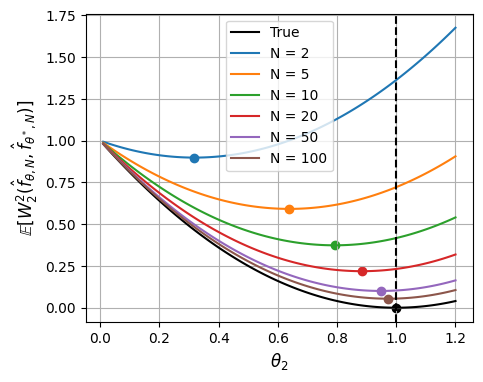

In [13]:
plt.figure(figsize=(5,4))
plt.plot(sig2_set, true_loss_gaussian_set, 'k', label='True')
plt.scatter(sigma1, 0, marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(sig2_set, expected_loss_gaussian_set[str(N)], label=f'N = {N}')
    # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    temp_sigma = expected_loss_gaussian_minimizer_set[str(N)]
    plt.scatter(temp_sigma, expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, temp_sigma, N, m1s=m1s_set[str(N)]), marker='o')
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_expected_loss_gaussian.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [21]:
sigma1s_ = sig2_set
expected_was_diagonal_ = np.empty((len(Nset), len(sigma1s_)))
for i, N in enumerate(Nset):
    for j, sig1 in enumerate(sigma1s_):
        expected_was_diagonal_[i,j] = expected_wasserstein_loss_gaussian(mu2, sig1, mu2, sig1, N, m1s=m1s_set[str(N)])

In [65]:
def plot_rawdata(sig2_set, raw_data, N, reg, key, color=None, ls='-', plot_scatter=True):
    if N == 'infty':
        label = rf'$\epsilon$ = {reg}, N = $\infty$'
    else:
        label = rf'$\epsilon$ = {reg}, N = {N}'
    if color is None:
        line, = plt.plot(sig2_set, raw_data, label=label, ls=ls)
    else:
        line, = plt.plot(sig2_set, raw_data, label=label, color=color, ls=ls)
    # f = interp1d(sig2_set, raw_data, kind='cubic')   # or 'quadratic', 'linear'
    spline = UnivariateSpline(sig2_set, raw_data, s=1, k=5)
    new_data = spline(sig2_set)
    # plt.plot(sig2_set, new_data, '--', color=line.get_color())
    res = minimize_scalar(spline, bounds=(sig2_set.min(), sig2_set.max()), method='bounded')
    x_min = res.x
    y_min = spline(x_min)
    if plot_scatter:
        plt.scatter(x_min, y_min, marker='o', color=line.get_color())
    print(f"reg: {reg}, x_min: {x_min:.4f}")
    return line

reg: 0.5, x_min: 0.7883
reg: 0.5, x_min: 0.8892
reg: 0.5, x_min: 1.0074
reg: 5, x_min: 0.7194
reg: 5, x_min: 0.8593
reg: 5, x_min: 1.0002


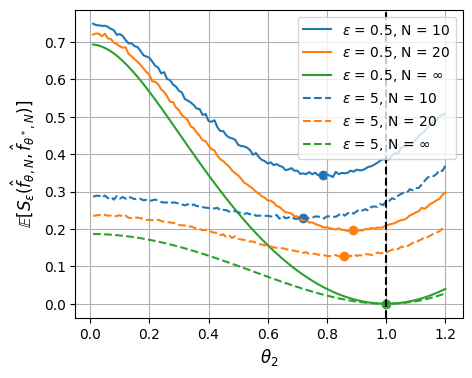

In [103]:
N_set_merge = [2, 5, 10, 20, 50, 100]
colors = []
# for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:

plt.figure(figsize=(5,4))
for j, reg in enumerate([0.5, 5]):
    runidx = 0
# for reg in [1]:
    for i,N in enumerate(N_set_merge):
        if N != 10 and N != 20:
            continue
    
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        
        if j == 0:
            line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')
            colors.append(line.get_color())
        else:
            plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full', color=colors[runidx], ls='--')
        
        runidx += 1
    if j == 0:
        line = plot_rawdata(sig2_set, sinkhorn_div_set[str(reg)], 'infty', reg, 'sink_div_full', plot_scatter=False)
        colors.append(line.get_color())
    else:
        plot_rawdata(sig2_set, sinkhorn_div_set[str(reg)], 'infty', reg, 'sink_div_full', color=colors[runidx], ls='--', plot_scatter=False)

# plt.ylim(0,0.2)
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.scatter(sigma1, 0, color=colors[-1])
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[S_{\epsilon}(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})]$', fontsize=12)
# plt.legend(loc='upper right')
plt.legend()
# plt.savefig(f'./fig_sinkhorn_gaussian.pdf', format='pdf', bbox_inches="tight", dpi=300)

reg: 0.5, x_min: 1.0026
reg: 0.5, x_min: 1.0079
reg: 0.5, x_min: 1.0074
reg: 5, x_min: 0.9998
reg: 5, x_min: 1.0013
reg: 5, x_min: 1.0002


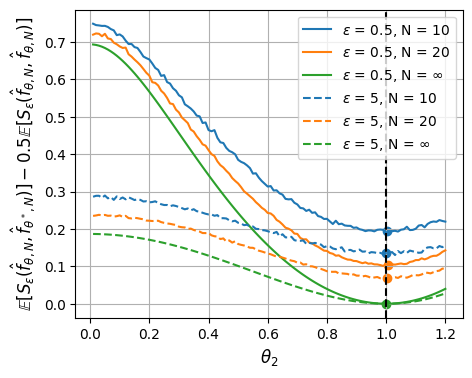

In [102]:
N_set_merge = [2, 5, 10, 20, 50, 100]
colors = []
# for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:

plt.figure(figsize=(5,4))
for j, reg in enumerate([0.5, 5]):
    runidx = 0
# for reg in [1]:
    for i,N in enumerate(N_set_merge):
        if N != 10 and N != 20:
            continue
    
         
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data_full = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        ent_part_self = results_merge[str(reg)]['ent_yy_indep'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'][i].mean(axis=-1))
        raw_data_self = results_merge[str(reg)]['sink_div_self'][i].mean(axis=-1) + reg*ent_part_self

        raw_data = raw_data_full - 0.5*raw_data_self
                
        
        if j == 0:
            line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')
            colors.append(line.get_color())
        else:
            plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full', color=colors[runidx], ls='--')

        runidx += 1
    if j == 0:
        line = plot_rawdata(sig2_set, sinkhorn_div_set[str(reg)], 'infty', reg, 'sink_div_full', plot_scatter=False)
        colors.append(line.get_color())
    else:
        plot_rawdata(sig2_set, sinkhorn_div_set[str(reg)], 'infty', reg, 'sink_div_full', color=colors[runidx], ls='--', plot_scatter=False)

# plt.ylim(0,0.2)
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.scatter(sigma1, 0, color=colors[-1])
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[S_{\epsilon}(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})] - 0.5\mathbb{E}[S_{\epsilon}(\hat{f}_{\theta, N}, \hat{f}_{\theta, N})]$', fontsize=12)
# plt.legend(loc='upper right')
plt.legend()
# plt.savefig(f'./fig_sinkhorn_gaussian_debias.pdf', format='pdf', bbox_inches="tight", dpi=300)

reg: 0, x_min: 0.8839
reg: 0.2, x_min: 0.8904
reg: 0.5, x_min: 0.8892
reg: 1, x_min: 0.8850
reg: 2, x_min: 0.8823
reg: 5, x_min: 0.8593
reg: 10, x_min: 0.7981
reg: 20, x_min: 0.6384
reg: 100, x_min: 0.0100


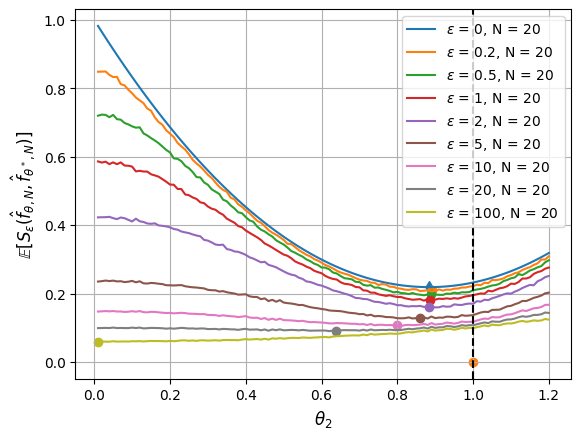

In [101]:
N_set_merge = [2, 5, 10, 20, 50, 100]
colors = []
# for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:

# plt.figure(figsize=(5,4))
for j, reg in enumerate([0.2, 0.5, 1, 2, 5, 10, 20, 100]):
    runidx = 0
# for reg in [1]:
    for i,N in enumerate(N_set_merge):
        if N != 20:
            continue

        if j == 0:
            plt.plot(sig2_set, expected_loss_gaussian_set[str(N)], label=rf'$\epsilon$ = 0, N = {N}')
            # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
            temp_sigma = expected_loss_gaussian_minimizer_set[str(N)]
            plt.scatter(temp_sigma, expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, temp_sigma, N, m1s=m1s_set[str(N)]), marker='d')
            print(f"reg: 0, x_min: {temp_sigma:.4f}")
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        
        if j == 0:
            line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')
            colors.append(line.get_color())
        else:
            plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')

        ent_part_self = results_merge[str(reg)]['ent_yy_indep'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'][i].mean(axis=-1))
        raw_data = results_merge[str(reg)]['sink_div_self'][i].mean(axis=-1) + reg*ent_part_self
        # plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_self_full')

        runidx += 1
    # if j == 0:
    #     line = plot_rawdata(sig2_set, sinkhorn_div_set[str(reg)], 'infty', reg, 'sink_div_full')
    #     colors.append(line.get_color())
    # else:
    #     plot_rawdata(sig2_set, sinkhorn_div_set[str(reg)], 'infty', reg, 'sink_div_full')

# plt.ylim(0,0.2)
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.scatter(sigma1, 0, color=colors[-1])
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[S_{\epsilon}(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})]$', fontsize=12)
# plt.legend(loc='upper right')
plt.legend()

reg: 1, x_min: 0.0100
reg: 1, x_min: 0.6293
reg: 1, x_min: 0.7941
reg: 1, x_min: 0.8850
reg: 1, x_min: 0.9488
reg: 1, x_min: 0.9725
reg: 1, x_min: 0.9982


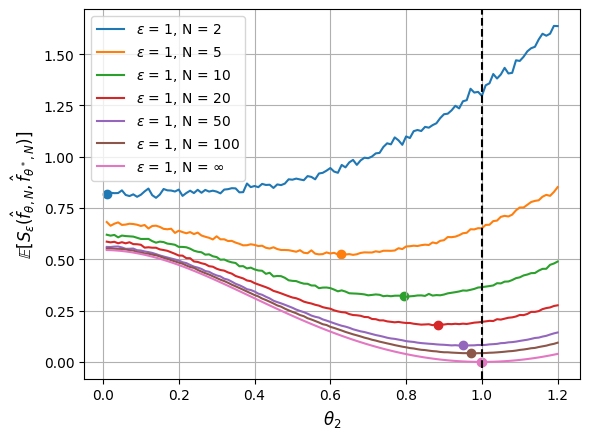

In [93]:
N_set_merge = [2, 5, 10, 20, 50, 100]
colors = []
# for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:

# plt.figure(figsize=(5,4))
# for j, reg in enumerate([0.2, 0.5, 1, 2, 5, 10, 20, 100]):
for j, reg in enumerate([1]):
    runidx = 0
    for i,N in enumerate(N_set_merge):
        # if N != 5:
        #     continue

        # if j == 0:
        #     plt.plot(sig2_set, expected_loss_gaussian_set[str(N)], label=rf'$\epsilon$ = 0, N = {N}')
        #     # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
        #     temp_sigma = expected_loss_gaussian_minimizer_set[str(N)]
        #     plt.scatter(temp_sigma, expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, temp_sigma, N, m1s=m1s_set[str(N)]), marker='d')
        #     print(f"reg: 0, x_min: {temp_sigma:.4f}")
        
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        
        if j == 0:
            line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')
            colors.append(line.get_color())
        else:
            plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')

        ent_part_self = results_merge[str(reg)]['ent_yy_indep'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'][i].mean(axis=-1))
        raw_data = results_merge[str(reg)]['sink_div_self'][i].mean(axis=-1) + reg*ent_part_self
        # plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_self_full')

        runidx += 1
    if j == 0:
        line = plot_rawdata(sig2_set, sinkhorn_div_set[str(reg)], 'infty', reg, 'sink_div_full')
        colors.append(line.get_color())
    else:
        plot_rawdata(sig2_set, sinkhorn_div_set[str(reg)], 'infty', reg, 'sink_div_full')

# plt.ylim(0,0.2)
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.scatter(sigma1, 0, color=colors[-1])
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[S_{\epsilon}(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})]$', fontsize=12)
# plt.legend(loc='upper right')
plt.legend()

In [25]:
# from raw means
dsig = 0.01
alpha_set = dict()
for reg in [0.2, 0.5, 1, 2, 5, 20, 100]:
    alphas = np.empty((len(N_set_merge), len(sig2_set)))
    raw1 = results_merge[str(reg)]['sink_div_emp'].mean(axis=-1)
    ent_part = results_merge[str(reg)]['ent_xy'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'].mean(axis=-1))
    raw1 += reg*ent_part
    raw1_deriv = np.zeros(raw1.shape)
    raw1_deriv[:,1:-1] = (raw1[:,2:] - raw1[:,:-2])/2/dsig
    raw1_deriv[:,0] = (raw1[:,1] - raw1[:,0])/dsig
    raw1_deriv[:,-1] = (raw1[:,-1] - raw1[:,-2])/dsig
    
    raw2 = results_merge[str(reg)]['sink_div_self'].mean(axis=-1)
    ent_part_self = results_merge[str(reg)]['ent_yy_indep'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'].mean(axis=-1))
    raw2 += reg*ent_part_self
    raw2_deriv = np.zeros(raw2.shape)
    raw2_deriv[:,1:-1] = (raw2[:,2:] - raw2[:,:-2])/2/dsig
    raw2_deriv[:,0] = (raw2[:,1] - raw2[:,0])/dsig
    raw2_deriv[:,-1] = (raw2[:,-1] - raw2[:,-2])/dsig
    
    alphas = raw1_deriv / raw2_deriv
    alpha_set[str(reg)] = alphas

(0.0, 5.0)

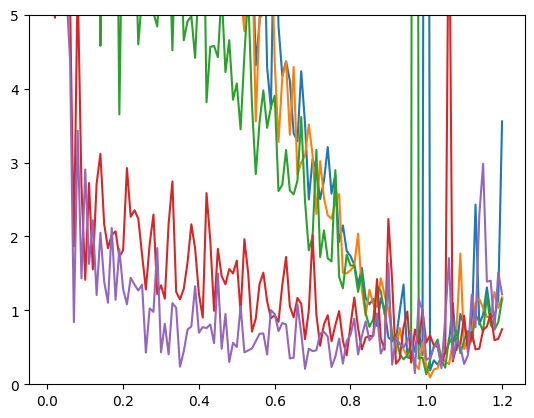

In [26]:
for reg in [1, 2, 5, 20, 100]:
    plt.plot(sig2_set/sigma1, np.std(alpha_set[str(reg)], axis=0), label=f'reg={reg}')
plt.ylim(0,5)

In [27]:
# from smoothed means
dsig = 0.01
alpha_set_smooth = dict()
s=1
k=5
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    alphas = np.empty((len(N_set_merge), len(sig2_set)))
    raw1_ = results_merge[str(reg)]['sink_div_emp'].mean(axis=-1)
    ent_part = results_merge[str(reg)]['ent_xy'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'].mean(axis=-1))
    raw1_ += reg*ent_part
    raw1 = np.zeros(raw1_.shape)
    for i in range(len(raw1)):
        spline = UnivariateSpline(sig2_set, raw1_[i], s=s, k=k)
        raw1[i] = spline(sig2_set)
    raw1_deriv = np.zeros(raw1.shape)
    raw1_deriv[:,1:-1] = (raw1[:,2:] - raw1[:,:-2])/2/dsig
    raw1_deriv[:,0] = (raw1[:,1] - raw1[:,0])/dsig
    raw1_deriv[:,-1] = (raw1[:,-1] - raw1[:,-2])/dsig
    
    raw2_ = results_merge[str(reg)]['sink_div_self'].mean(axis=-1)
    ent_part_self = results_merge[str(reg)]['ent_yy_indep'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'].mean(axis=-1))
    raw2_ += reg*ent_part_self
    raw2 = np.zeros(raw2_.shape)
    for i in range(len(raw2)):
        spline = UnivariateSpline(sig2_set, raw2_[i], s=s, k=k)
        raw2[i] = spline(sig2_set)
    raw2_deriv = np.zeros(raw2.shape)
    raw2_deriv[:,1:-1] = (raw2[:,2:] - raw2[:,:-2])/2/dsig
    raw2_deriv[:,0] = (raw2[:,1] - raw2[:,0])/dsig
    raw2_deriv[:,-1] = (raw2[:,-1] - raw2[:,-2])/dsig
    
    alphas = raw1_deriv / raw2_deriv
    alpha_set_smooth[str(reg)] = alphas

    

reg: 0.2, sig: 1.01, ratio: 1.0100, alpha_mean: 0.4707, alpha_std: 0.0264
reg: 0.5, sig: 1.01, ratio: 1.0100, alpha_mean: 0.5131, alpha_std: 0.0146
reg: 1, sig: 1.00, ratio: 1.0000, alpha_mean: 0.5118, alpha_std: 0.0121
reg: 2, sig: 1.00, ratio: 1.0000, alpha_mean: 0.5193, alpha_std: 0.0219
reg: 5, sig: 1.00, ratio: 1.0000, alpha_mean: 0.4977, alpha_std: 0.0022
reg: 10, sig: 1.00, ratio: 1.0000, alpha_mean: 0.4974, alpha_std: 0.0044
reg: 20, sig: 1.00, ratio: 1.0000, alpha_mean: 0.4990, alpha_std: 0.0072
reg: 100, sig: 1.00, ratio: 1.0000, alpha_mean: 0.4998, alpha_std: 0.0059


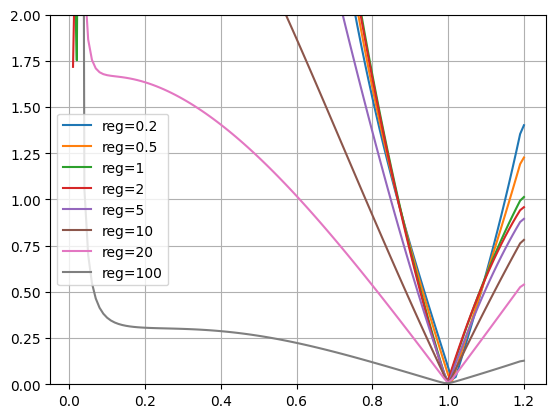

In [29]:
sig2_from_alpha_set = dict()
alpha_dagger_set = dict()
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    cur_std = np.std(alpha_set_smooth[str(reg)], axis=0)
    plt.plot(sig2_set/sigma1, cur_std, label=f'reg={reg}')
    idx = np.argmin(cur_std)
    sig2_from_alpha_set[str(reg)] = sig2_set[idx]
    alpha_dagger_set[str(reg)] = np.mean(alpha_set_smooth[str(reg)][:,idx])
    print(f"reg: {reg}, sig: {sig2_set[idx]:.2f}, ratio: {sig2_set[idx]/sigma1:.4f}, alpha_mean: {np.mean(alpha_set_smooth[str(reg)][:,idx]):.4f}, alpha_std: {np.std(alpha_set_smooth[str(reg)][:,idx]):.4f}")
plt.ylim([0,2])
plt.grid()
plt.legend()

reg: 0.2, sig: 1.0140, ratio: 1.0140, alpha_mean: 0.4941, alpha_std: 0.0032
reg: 0.5, sig: 1.0079, ratio: 1.0079, alpha_mean: 0.5006, alpha_std: 0.0045
reg: 1, sig: 0.9983, ratio: 0.9983, alpha_mean: 0.5021, alpha_std: 0.0054
reg: 2, sig: 0.9966, ratio: 0.9966, alpha_mean: 0.4999, alpha_std: 0.0021
reg: 5, sig: 1.0000, ratio: 1.0000, alpha_mean: 0.4976, alpha_std: 0.0022
reg: 10, sig: 1.0007, ratio: 1.0007, alpha_mean: 0.5000, alpha_std: 0.0033
reg: 20, sig: 1.0009, ratio: 1.0009, alpha_mean: 0.5009, alpha_std: 0.0069
reg: 100, sig: 0.9966, ratio: 0.9966, alpha_mean: 0.4979, alpha_std: 0.0055


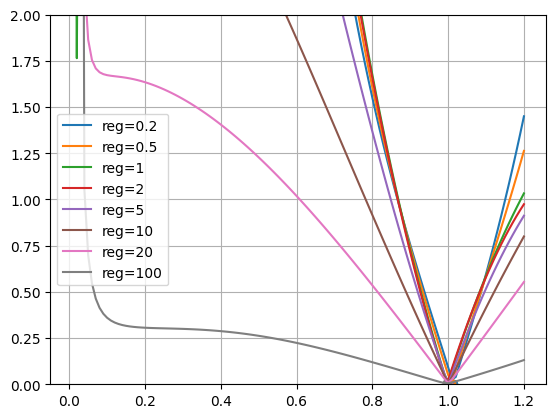

In [30]:
# from smoothed means
dsig = 0.01
alpha_set_smooth_v2 = dict()
sig2_from_alpha_set_v2 = dict()
alpha_dagger_set_v2 = dict()
s=1
k=5
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    raw1_ = results_merge[str(reg)]['sink_div_emp'].mean(axis=-1)
    ent_part = results_merge[str(reg)]['ent_xy'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'].mean(axis=-1))
    raw1_ += reg*ent_part
    dsplines = dict()
    for i, N in enumerate(N_set_merge):
        spline = UnivariateSpline(sig2_set, raw1_[i], s=s, k=k)
        dsplines[str(N)] = spline.derivative()
    
    raw2_ = results_merge[str(reg)]['sink_div_self'].mean(axis=-1)
    ent_part_self = results_merge[str(reg)]['ent_yy_indep'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'].mean(axis=-1))
    raw2_ += reg*ent_part_self
    dsplines_self = dict()
    for i, N in enumerate(N_set_merge):
        spline = UnivariateSpline(sig2_set, raw2_[i], s=s, k=k)
        dsplines_self[str(N)] = spline.derivative()

    def alpha_var_func(sig, return_alpha=False):
        temp_alpha = []
        for i, N in enumerate(N_set_merge):
            temp_alpha.append(dsplines[str(N)](sig) / dsplines_self[str(N)](sig))
        if return_alpha:
            return np.var(temp_alpha, axis=0), np.array(temp_alpha)
        return np.var(temp_alpha, axis=0)
        
    res = minimize_scalar(alpha_var_func, bounds=(sig2_set.min(), sig2_set.max()), method='bounded')
    x_min = res.x
    val, alphas = alpha_var_func(x_min, return_alpha=True)
    
    alpha_set_smooth_v2[str(reg)] = alphas

    _, cur_alphas = alpha_var_func(sig2_set, return_alpha=True)
    cur_std = np.std(cur_alphas, axis=0)
    plt.plot(sig2_set/sigma1, cur_std, label=f'reg={reg}')
    plt.scatter(x_min/sigma1, np.sqrt(val))
    sig2_from_alpha_set_v2[str(reg)] = x_min
    alpha_dagger_set_v2[str(reg)] = np.mean(alpha_set_smooth_v2[str(reg)])
    print(f"reg: {reg}, sig: {x_min:.4f}, ratio: {x_min/sigma1:.4f}, alpha_mean: {np.mean(alpha_set_smooth_v2[str(reg)]):.4f}, alpha_std: {np.std(alpha_set_smooth_v2[str(reg)]):.4f}")
plt.ylim([0,2])
plt.grid()
plt.legend()

(48, 120)
1.0, [0.49445135 0.4843916  0.46672233 0.43369547 0.36296278 0.23187646
 0.49416946 0.49313935 0.49517245 0.46849093 0.42460602 0.35631345
 0.49764325 0.50584661 0.50725947 0.50318995 0.52802438 0.52877559
 0.49894299 0.50032063 0.50816033 0.51567237 0.53042556 0.56221448
 0.49429905 0.50018919 0.50036893 0.49594211 0.49743974 0.49811525
 0.50266351 0.49444139 0.50285624 0.49517424 0.49865911 0.49088966
 0.48988906 0.50565965 0.50874559 0.49378509 0.50365336 0.4925578
 0.49953269 0.49334897 0.50336787 0.4913067  0.50785609 0.50356656]


(0.0, 10.0)

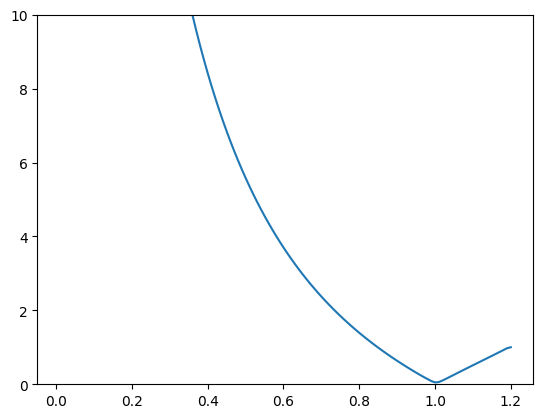

In [31]:
alpha_stack = []
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    alpha_stack.append(alpha_set_smooth[str(reg)])
alpha_stack = np.concatenate(alpha_stack)
print(alpha_stack.shape)
cur_std = np.std(alpha_stack, axis=0)
plt.plot(sig2_set/sigma1, cur_std, label=f'reg={reg}')
idx = np.argmin(cur_std)
print(f"{sig2_set[idx]/sigma1}, {alpha_stack[:,idx]}")
plt.ylim([0,10])

reg: 1, x_min: 1.0184
reg: 1, x_min: 0.9953
reg: 1, x_min: 0.9972
reg: 1, x_min: 0.9997
reg: 1, x_min: 0.9973
reg: 1, x_min: 0.9986
sig from alpha: 0.9983


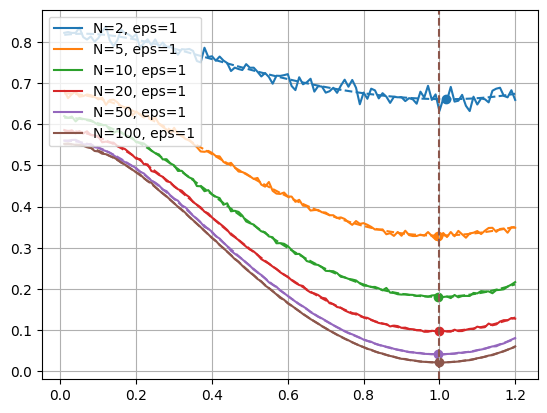

In [33]:
N_set_merge = [2, 5, 10, 20, 50, 100]
sig2_set=np.linspace(0.01,1.2,120)
for i,N in enumerate(N_set_merge):
    # if N != 100:
    #     continue
    # alpha = 0.5
    # alpha = 0
    # line, = plt.plot(sig2_set, expected_loss_gaussian_set[str(N)] - alpha*expected_was_diagonal_[i], label=f'N = {N}, eps=0')
    # # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    # plt.scatter(temp_sigma, expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, temp_sigma, N, m1s=m1s_set[str(N)]) \
    #             - alpha*expected_wasserstein_loss_gaussian(mu2, temp_sigma, mu2, temp_sigma, N, m1s=m1s_set[str(N)]), marker='d')
    
    # plt.axvline([sigma1], color=line.get_color(), linestyle="dashed")
    # print(f"reg: 0, x_min: {temp_sigma:.4f}, N:{N}")
    # for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    for reg in [1]:
        alpha = alpha_dagger_set_v2[str(reg)]
        # alpha = 0
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data_full = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        # plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')

        ent_part_self = results_merge[str(reg)]['ent_yy_indep'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'][i].mean(axis=-1))
        raw_data_self = results_merge[str(reg)]['sink_div_self'][i].mean(axis=-1) + reg*ent_part_self
        
        raw_data = raw_data_full - alpha*raw_data_self
        line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias')
        


plt.axvline([sig2_from_alpha_set_v2[str(reg)]], color=line.get_color(), linestyle="dashed")
print(f"sig from alpha: {sig2_from_alpha_set_v2[str(reg)]:.4f}")
# plt.ylim(0,0.2)
plt.grid()
plt.legend(loc='upper left')